### Cell 1: Environment Setup & Imports

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import cycle

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Set styling for academic plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

# Seed for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### Cell 2: Robust Path Resolution & Data Assembly

In [3]:
# The path you provided, with a fallback just in case Kaggle mounts it at the root of /input/
PRIMARY_PATH = "/kaggle/input/datasets/sumn2u/garbage-classification-v2"
FALLBACK_PATH = "/kaggle/input/garbage-classification-v2"

if os.path.exists(PRIMARY_PATH):
    DATA_DIR = Path(PRIMARY_PATH)
elif os.path.exists(FALLBACK_PATH):
    DATA_DIR = Path(FALLBACK_PATH)
else:
    # Auto-detect if nested
    found_dirs = glob.glob("/kaggle/input/**/*.jpg", recursive=True)
    if found_dirs:
        DATA_DIR = Path(found_dirs[0]).parent.parent
    else:
        raise FileNotFoundError("Dataset not found. Please verify the dataset path in Kaggle.")

print(f"Using Dataset Directory: {DATA_DIR}")

filepaths = list(DATA_DIR.glob(r'**/*.jpg')) + list(DATA_DIR.glob(r'**/*.png'))
labels = [filepath.parent.name for filepath in filepaths]

df = pd.DataFrame({
    'filepath': [str(fp) for fp in filepaths],
    'label': labels
})

classes = sorted(list(df['label'].unique()))
num_classes = len(classes)
print(f"Found {len(df)} images across {num_classes} classes: {classes}")

Using Dataset Directory: /kaggle/input/datasets/sumn2u/garbage-classification-v2
Found 36774 images across 10 classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


### Cell 3: Exploratory Data Analysis (EDA) - Class Distribution

/tmp/ipykernel_58/2413001988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')


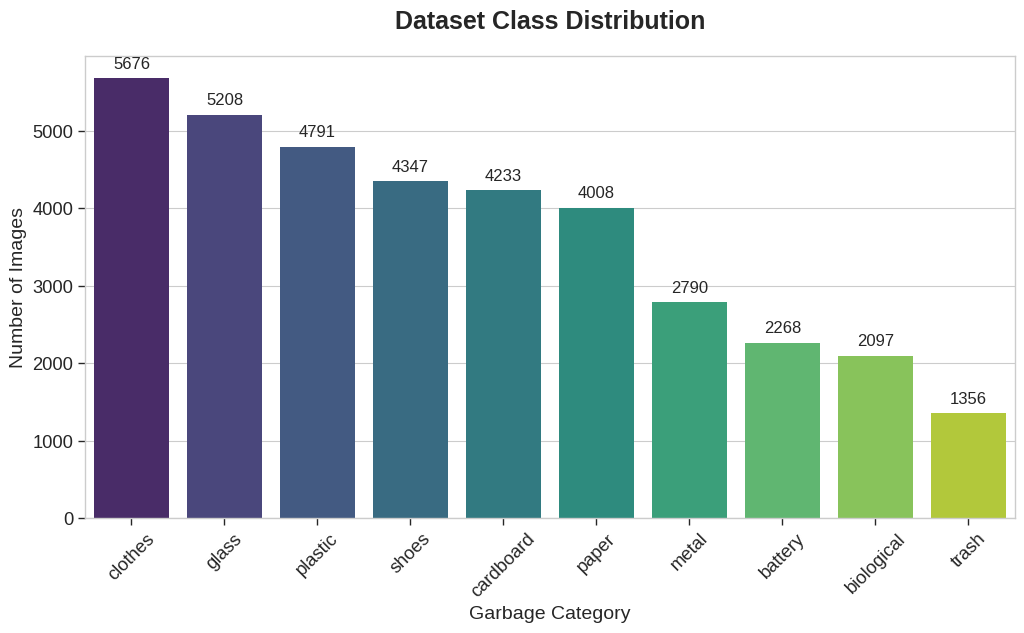

In [4]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Dataset Class Distribution', pad=20, fontsize=18, fontweight='bold')
plt.xlabel('Garbage Category', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.xticks(rotation=45)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# Save for paper
plt.savefig('/kaggle/working/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Cell 4: EDA - Sample Grid for Paper

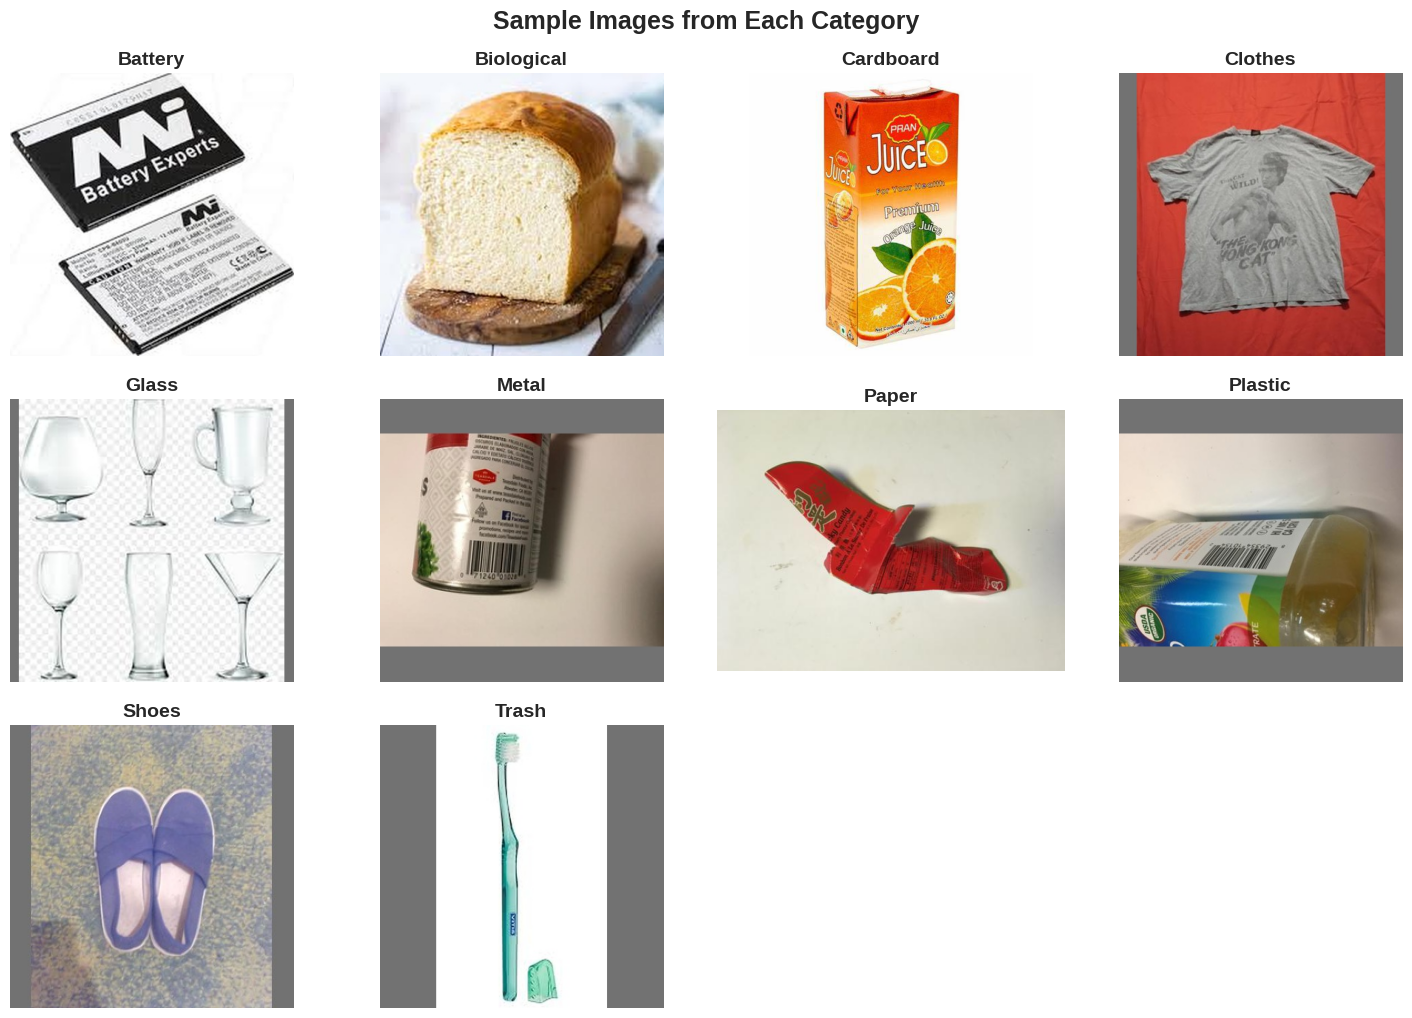

In [5]:
plt.figure(figsize=(15, 10))
for i, category in enumerate(classes):
    # Get a random image from each class
    sample = df[df['label'] == category].sample(1, random_state=SEED).iloc[0]
    img = plt.imread(sample['filepath'])
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(category.capitalize(), fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Sample Images from Each Category", y=1.02, fontsize=18, fontweight='bold')
plt.savefig('/kaggle/working/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

### Cell 5: Data Splitting and Generators

In [6]:
# Stratified split to maintain class ratios
train_df, dummy_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(dummy_df, test_size=0.50, stratify=dummy_df['label'], random_state=SEED)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Train Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Val and Test Generators (No Augmentation, only scaling)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen = test_datagen.flow_from_dataframe(val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = test_datagen.flow_from_dataframe(test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Train size: 25741 | Val size: 5516 | Test size: 5517
Found 25741 validated image filenames belonging to 10 classes.
Found 5516 validated image filenames belonging to 10 classes.
Found 5517 validated image filenames belonging to 10 classes.


### Cell 6: Model Architecture Definition

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers initially
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('/kaggle/working/best_resnet50_model.h5', save_best_only=True, monitor='val_accuracy'),
    CSVLogger('/kaggle/working/training_logs.csv') # Saves epoch data for your paper tables
]

model.summary()

I0000 00:00:1783878285.618108      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783878285.621169      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 1,054,218 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Cell 7: Training Phase

In [ ]:
EPOCHS = 50

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
  2/805 ━━━━━━━━━━━━━━━━━━━━ 1:01 77ms/step - accuracy: 0.0391 - loss: 2.7836      

I0000 00:00:1783878305.162223     175 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.1734 - loss: 2.2209

805/805 ━━━━━━━━━━━━━━━━━━━━ 508s 614ms/step - accuracy: 0.1872 - loss: 2.1607 - val_accuracy: 0.2252 - val_loss: 2.0489 - learning_rate: 0.0010
Epoch 2/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.2185 - loss: 2.1006

805/805 ━━━━━━━━━━━━━━━━━━━━ 331s 411ms/step - accuracy: 0.2206 - loss: 2.0908 - val_accuracy: 0.2843 - val_loss: 2.0058 - learning_rate: 0.0010
Epoch 3/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.2287 - loss: 2.0658

...

805/805 ━━━━━━━━━━━━━━━━━━━━ 331s 411ms/step - accuracy: 0.3202 - loss: 1.8930 - val_accuracy: 0.3939 - val_loss: 1.7267 - learning_rate: 5.0000e-04
Epoch 28/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.3204 - loss: 1.8774

805/805 ━━━━━━━━━━━━━━━━━━━━ 338s 419ms/step - accuracy: 0.3209 - loss: 1.8837 - val_accuracy: 0.3987 - val_loss: 1.7409 - learning_rate: 5.0000e-04
Epoch 29/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.3192 - loss: 1.8912

805/805 ━━━━━━━━━━━━━━━━━━━━ 340s 422ms/step - accuracy: 0.3233 - loss: 1.8840 - val_accuracy: 0.4054 - val_loss: 1.7216 - learning_rate: 5.0000e-04
Epoch 30/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 336s 418ms/step - accuracy: 0.3256 - loss: 1.8808 - val_accuracy: 0.3968 - val_loss: 1.7439 - learning_rate: 5.0000e-04
Epoch 31/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 334s 414ms/step - accuracy: 0.3271 - loss: 1.8774 - val_accuracy: 0.3981 - val_loss: 1.7244 - learning_rate: 5.0000e-04
Epoch 32/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 335s 416ms/step - accuracy: 0.3245 - loss: 1.8802 - val_accuracy: 0.4008 - val_loss: 1.7062 - learning_rate: 5.0000e-04
Epoch 33/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 331s 411ms/step - accuracy: 0.3275 - loss: 1.8669 - val_accuracy: 0.3898 - val_loss: 1.7206 - learning_rate: 5.0000e-04
Epoch 34/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 332s 413ms/step - accuracy: 0.3296 - loss: 1.8694 - val_accuracy: 0.3978 - val_loss: 1.7209 - learning_rate: 5.0000e-04
Epoch 35/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 331s 

805/805 ━━━━━━━━━━━━━━━━━━━━ 334s 415ms/step - accuracy: 0.3380 - loss: 1.8479 - val_accuracy: 0.4202 - val_loss: 1.6708 - learning_rate: 2.5000e-04
Epoch 37/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 332s 413ms/step - accuracy: 0.3330 - loss: 1.8523 - val_accuracy: 0.4104 - val_loss: 1.6846 - learning_rate: 2.5000e-04
Epoch 38/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.3326 - loss: 1.8474

805/805 ━━━━━━━━━━━━━━━━━━━━ 332s 413ms/step - accuracy: 0.3358 - loss: 1.8490 - val_accuracy: 0.4222 - val_loss: 1.6706 - learning_rate: 2.5000e-04
Epoch 39/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 330s 410ms/step - accuracy: 0.3424 - loss: 1.8399 - val_accuracy: 0.4206 - val_loss: 1.6586 - learning_rate: 2.5000e-04
Epoch 40/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 333s 414ms/step - accuracy: 0.3399 - loss: 1.8448 - val_accuracy: 0.4210 - val_loss: 1.6699 - learning_rate: 2.5000e-04
Epoch 41/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 353s 438ms/step - accuracy: 0.3429 - loss: 1.8376 - val_accuracy: 0.4219 - val_loss: 1.6674 - learning_rate: 2.5000e-04
Epoch 42/50
 28/805 ━━━━━━━━━━━━━━━━━━━━ 5:20 413ms/step - accuracy: 0.3595 - loss: 1.8172

### Cell 8: Plotting Learning Curves

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy Plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax[0].set_title('Model Accuracy over Epochs', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Epoch', fontsize=14)
ax[0].set_ylabel('Accuracy', fontsize=14)
ax[0].legend(loc='lower right')

# Loss Plot
ax[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
ax[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax[1].set_title('Model Loss over Epochs', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Epoch', fontsize=14)
ax[1].set_ylabel('Loss', fontsize=14)
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('/kaggle/working/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Cell 9: Evaluation & Detailed Predictions

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen, steps=np.ceil(len(test_df)/BATCH_SIZE))
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Get true labels and predicted probabilities
test_gen.reset()
Y_pred_probs = model.predict(test_gen, steps=np.ceil(len(test_df)/BATCH_SIZE))
y_pred = np.argmax(Y_pred_probs, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

### Cell 10: Academic Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels, annot_kws={"size": 12})
plt.title('Confusion Matrix on Test Set', pad=20, fontsize=18, fontweight='bold')
plt.ylabel('True Class', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Cell 11: Classification Report

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Save to CSV for easy copy-pasting into Word/LaTeX
report_df.to_csv('/kaggle/working/classification_report.csv')

print("Classification Report saved to /kaggle/working/classification_report.csv")
display(report_df.round(4))

### Cell 12: ROC-AUC Curves (One-vs-Rest)

In [ ]:
# Binarize labels for One-vs-Rest ROC
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(12, 8))
colors = cycle(plt.cm.tab10.colors)

for i, color in zip(range(num_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], Y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) per Class', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)

plt.savefig('/kaggle/working/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Cell 13: Precision-Recall Curves

In [ ]:
plt.figure(figsize=(12, 8))

for i, color in zip(range(num_classes), colors):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], Y_pred_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color, lw=2,
             label=f'PR curve of {class_labels[i]} (area = {pr_auc:0.2f})')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve per Class', fontsize=16, fontweight='bold')
plt.legend(loc="lower left", fontsize=10)

plt.savefig('/kaggle/working/pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()